In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import warnings 

warnings.filterwarnings("ignore")


In [95]:
df = pd.read_csv("C:\\Desktop\\visa approval prediction\\us_visa approval prediction\\data\\raw\\EasyVisa.csv")

# From EDA we found out that the datasets have no missing and duplicate values 
# If found out missing value and duplicates we remove it 

# If Missing and duplicate value exist 
# df.drop_duplicates().sum()
# numeric_features=df.select_dtypes(exclude=["object"]).columns
# categorical_features=df.select_dtypes(include=["object"]).columns.difference(["case_id"])
# df[numeric_features].fillna(df[numeric_features].median())
# df[categorical_features].fillna(df[categorical_features].mode())

In [96]:
# First we will drop the case_ID column as it have no effect on the model training 

df.drop("case_id",inplace=True, axis=1)
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   continent              25480 non-null  str    
 1   education_of_employee  25480 non-null  str    
 2   has_job_experience     25480 non-null  str    
 3   requires_job_training  25480 non-null  str    
 4   no_of_employees        25480 non-null  int64  
 5   yr_of_estab            25480 non-null  int64  
 6   region_of_employment   25480 non-null  str    
 7   prevailing_wage        25480 non-null  float64
 8   unit_of_wage           25480 non-null  str    
 9   full_time_position     25480 non-null  str    
 10  case_status            25480 non-null  str    
dtypes: float64(1), int64(2), str(8)
memory usage: 3.0 MB


Feature Engineering 

In [97]:
from datetime import date

# creating date object of today's date
today_date = date.today()
current_year=today_date.year
# We determine the company age by subtracting the current year with year of establishment 
df["company_age"] = current_year-df["yr_of_estab"]
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,19
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,24
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,18
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,129
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,21


In [98]:
# Replace yr_of_estab with company_age

df.drop("yr_of_estab",inplace=True, axis=1)
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,Asia,High School,N,N,14513,West,592.2029,Hour,Y,Denied,19
1,Asia,Master's,Y,N,2412,Northeast,83425.6500,Year,Y,Certified,24
2,Asia,Bachelor's,N,Y,44444,West,122996.8600,Year,Y,Denied,18
3,Asia,Bachelor's,N,N,98,West,83434.0300,Year,Y,Denied,129
4,Africa,Master's,Y,N,1082,South,149907.3900,Year,Y,Certified,21


In [99]:
# Split the df into X and Y 

x = df.drop("case_status",axis=1)
y = df["case_status"]

# Features type
print(x.dtypes)
num_features = x.select_dtypes(include=["float64","int64"]).columns
cat_features = x.select_dtypes(include=["str"]).columns



continent                    str
education_of_employee        str
has_job_experience           str
requires_job_training        str
no_of_employees            int64
region_of_employment         str
prevailing_wage          float64
unit_of_wage                 str
full_time_position           str
company_age                int64
dtype: object


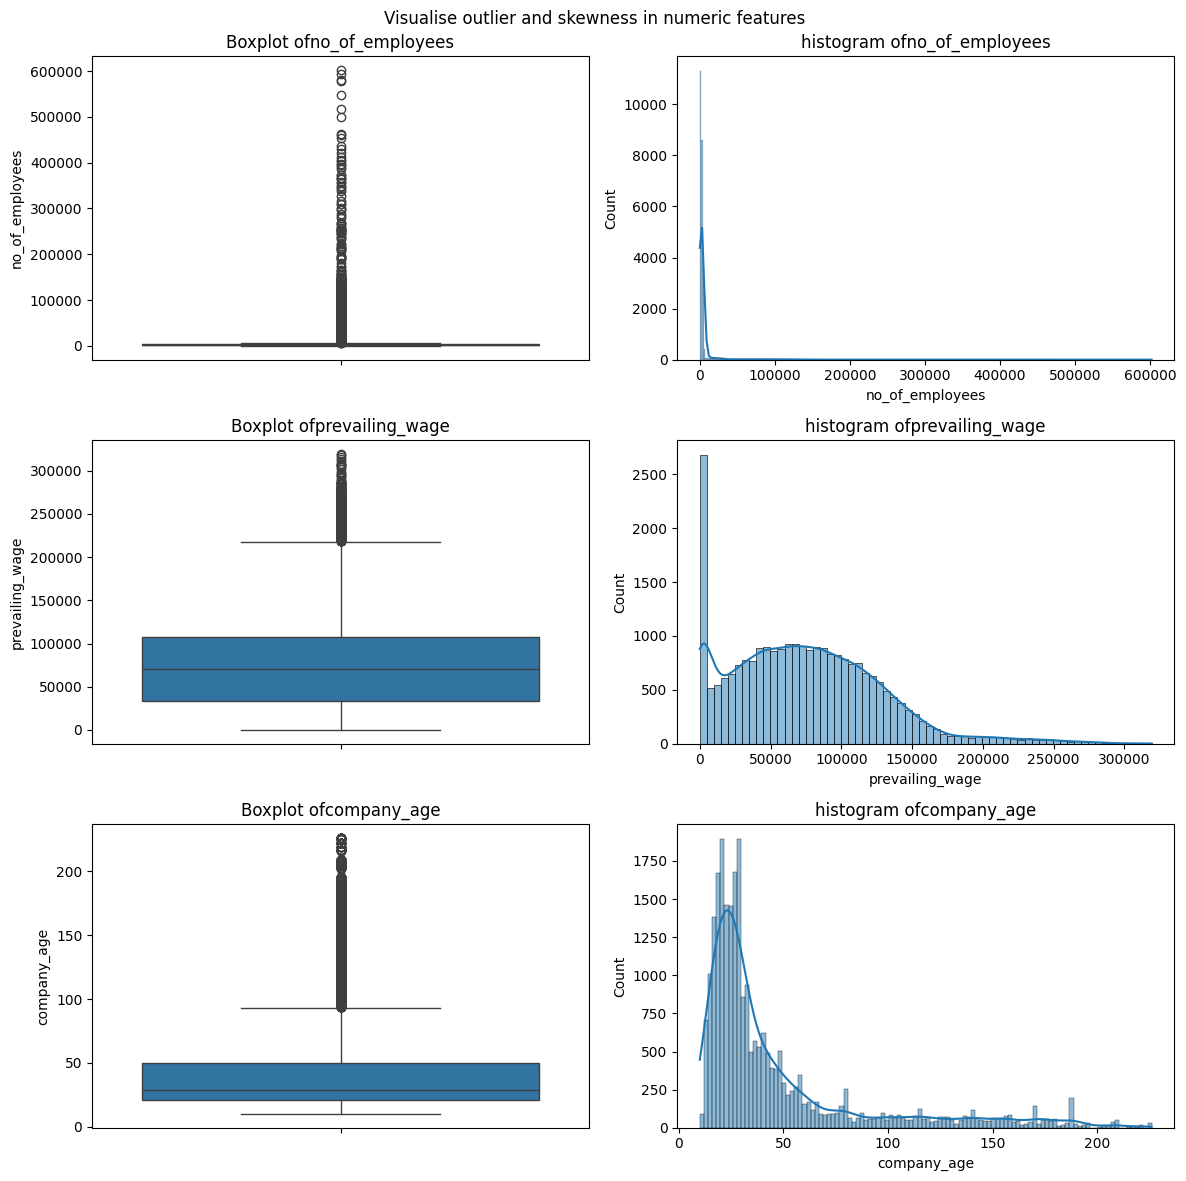

In [100]:
# There are outlier and skewness issues in columns no_of_employee,prevailing_wage and company_age 
# visualise the outlier and skewness 

fig,ax = plt.subplots(3,2,figsize=(12,12))
fig.suptitle("Visualise outlier and skewness in numeric features")
for i, col in enumerate(num_features):
    sb.boxplot(data=df,y=col,ax=ax[i,0])
    ax[i,0].set_title(f"Boxplot of{col}")
    sb.histplot(data=df,x=col,kde=True,ax=ax[i,1])
    ax[i,1].set_title(f"histogram of{col}")
plt.tight_layout()

In [101]:
# Skewness = distortion from normal distribution (sysmetric bell curve)
print("Detect skewness of the numberic features")
df[num_features].skew()

Detect skewness of the numberic features


no_of_employees    12.265260
prevailing_wage     0.755776
company_age         2.037301
dtype: float64

Interpretation

Skewness = measures asymmetry of the distribution
  = 0          : perfectly symmetric (normal)
  > 0          : right-skewed — long tail to the RIGHT
  < 0          : left-skewed  — long tail to the LEFT
  |skew| < 0.5 : approximately normal        
  |skew| 0.5–1 : moderately skewed           
  |skew| > 1   : highly skewed  transformation needed
 
Kurtosis  → measures heaviness of tails (peakedness)
  = 0  : normal tails (mesokurtic)
  > 0  : heavier tails, more extreme outliers (leptokurtic)
  < 0  : lighter tails, fewer outliers (platykurtic)
  

1. no_of_employee = extreme positive right skewed [long tail extremely extend right]

2. prevailing_wage = slightly positive right skewed [long tail extend right] 

3. company_age = extreme positive right skewed [long tail extend right]

In [102]:
# we do features engineering after train/test split to prevent data leakage 

# Choose transformer that suite for the skew outlier 
# Power transformer
# log/Log1p   (not for negative skew)- best suit strong right skew
# square root (not for negative skew)- moderate right skew
# Box Cox     (not for negative) - right skew, strictly for positive
# Yeo-Johnson (both negative,positive) - Any skew any sign

# Choose encoder 
# One hot encoder = handle lesser uniqie values and not ordinal
# Ordinal encoding = handle many unique categories and ordinal ranking does matter

# standard scaler = removing mean and scaling to unit variance 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler,OrdinalEncoder,PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

# Define columns corretly
oh_columns = ['continent',"region_of_employment"]  # these 2 features are nominal without inherent order
or_columns = ["education_of_employee","has_job_experience","requires_job_training","full_time_position","unit_of_wage"]  # these features are with unique ordinal 
scaler_columns = ["no_of_employees","company_age"]
transform_columns = ["prevailing_wage"] 

# Define individual transformer
numeric_transformer = StandardScaler() 
# drop = first =remove one dummy to avoild muticollinearity
oh_encoder = OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False)
or_encoder = OrdinalEncoder()
power_transformer = PowerTransformer(method="yeo-johnson",standardize=True) # power trnasform and scaling in one step

# Assemble columntransformer
preprocessor_pipeline = ColumnTransformer(
    transformers=[
        ("onehot", oh_encoder, oh_columns),
        ("ordinal",or_encoder,or_columns),
        ("power", power_transformer,transform_columns),
        ("standardscaler", numeric_transformer,scaler_columns)
    ],
    remainder="drop" # drop others unrelated columns like target variable
    )

In [103]:
x_train_transformed = preprocessor_pipeline.fit_transform(x_train)
x_test_transformed = preprocessor_pipeline.transform(x_test)

In [104]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [105]:
# define evaluation functin for classification metrics

def evaluate_classifier(y_true,y_predicted,y_probability=None,pos_label="Certified"):
    acc = accuracy_score(y_true, y_predicted) # Calculate Accuracy
    f1 = f1_score(y_true, y_predicted,pos_label = pos_label,zero_division=0) # Calculate F1-score
    precision = precision_score(y_true, y_predicted,pos_label=pos_label,zero_division=0) # Calculate Precision
    recall = recall_score(y_true, y_predicted,pos_label=pos_label,zero_division=0)  # Calculate Recall
    roc_input = y_probability if y_probability is not None else y_predicted
    roc_auc = roc_auc_score(y_true, roc_input) #Calculate Roc
    return acc, f1 , precision, recall, roc_auc

In [106]:
# Define models with dictionary form

models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
     "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(eval_metric="logloss"), 
     "CatBoosting Classifier": CatBoostClassifier(verbose=False),
     "Support Vector Classifier": SVC(probability=True),
    "AdaBoost Classifier": AdaBoostClassifier()

}

In [117]:
# Create a function which evaluate models and return a report

def evaluate_models(x_train,x_test,y_train,y_test,models, pos_label="Certified"):

    # Encode stringlabel to 0/1 for XGBoost compatibility
    le=LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc = le.transform(y_test)
    pos_idx = list(le.classes_).index(pos_label) if pos_label in le.classes_ else None


    record = []

    for name, model in models.items():

          # XGBoost needs encoded labels; all others work with both
        if "XGB" in name:
            model.fit(x_train, y_train_enc)
            y_train_pred = le.inverse_transform(model.predict(x_train))
            y_test_pred  = le.inverse_transform(model.predict(x_test))
            y_train_prob = model.predict_proba(x_train)[:, pos_idx]
            y_test_prob  = model.predict_proba(x_test)[:, pos_idx]
        else:
            model.fit(x_train, y_train)
            y_train_pred = model.predict(x_train)
            y_test_pred  = model.predict(x_test)
            if hasattr(model, "predict_proba"):
                col          = list(model.classes_).index(pos_label)
                y_train_prob = model.predict_proba(x_train)[:, col]
                y_test_prob  = model.predict_proba(x_test)[:, col]
            else:
                y_train_prob = None
                y_test_prob  = None

    
        # Metrics
        train_acc, train_f1, train_precision, train_recall, train_roc = evaluate_classifier(y_train, y_train_pred, y_train_prob, pos_label=pos_label)
        test_acc,  test_f1,  test_precision,  test_recall,  test_roc  = evaluate_classifier(y_test,  y_test_pred,  y_test_prob, pos_label=pos_label)

        # Print results
        print(f"\n{'=' * 45}")
        print(f"  {name}")
        print(f"{'=' * 45}")
        print(f"  Model performance for Training Set")
        print(f"  - Accuracy  : {train_acc:.4f}")
        print(f"  - F1 Score  : {train_f1:.4f}")
        print(f"  - Precision : {train_precision:.4f}")
        print(f"  - Recall    : {train_recall:.4f}")
        print(f"  - ROC-AUC   : {train_roc:.4f}")
        print(f"  {'-' * 35}")
        print(f"  Model performance for Test Set")
        print(f"  - Accuracy  : {test_acc:.4f}")
        print(f"  - F1 Score  : {test_f1:.4f}")
        print(f"  - Precision : {test_precision:.4f}")
        print(f"  - Recall    : {test_recall:.4f}")
        print(f"  - ROC-AUC   : {test_roc:.4f}")
 
        record.append({
            "Model"          : name,
            "Train_Accuracy" : train_acc,
            "Train_F1"       : train_f1,
            "Train_Precision": train_precision,
            "Train_Recall"   : train_recall,
            "Train_ROC_AUC"  : train_roc,
            "Test_Accuracy"  : test_acc,
            "Test_F1"        : test_f1,
            "Test_Precision" : test_precision,
            "Test_Recall"    : test_recall,
            "Test_ROC_AUC"   : test_roc,
        })
 
   
    report = pd.DataFrame(record).sort_values(by="Test_Accuracy", ascending=False).reset_index(drop=True)
    return report


In [118]:
base_model_report = evaluate_models(
    x_train=x_train_transformed,
    x_test=x_test_transformed,
    y_train=y_train,
    y_test=y_test,
    models=models,
    pos_label="Certified"
)
print(base_model_report.to_string(index=False))


  Random Forest
  Model performance for Training Set
  - Accuracy  : 1.0000
  - F1 Score  : 1.0000
  - Precision : 1.0000
  - Recall    : 1.0000
  - ROC-AUC   : 0.0000
  -----------------------------------
  Model performance for Test Set
  - Accuracy  : 0.7190
  - F1 Score  : 0.8002
  - Precision : 0.7621
  - Recall    : 0.8422
  - ROC-AUC   : 0.2525

  Decision Tree
  Model performance for Training Set
  - Accuracy  : 1.0000
  - F1 Score  : 1.0000
  - Precision : 1.0000
  - Recall    : 1.0000
  - ROC-AUC   : 0.0000
  -----------------------------------
  Model performance for Test Set
  - Accuracy  : 0.6464
  - F1 Score  : 0.7356
  - Precision : 0.7348
  - Recall    : 0.7365
  - ROC-AUC   : 0.3992

  Gradient Boosting
  Model performance for Training Set
  - Accuracy  : 0.7539
  - F1 Score  : 0.8250
  - Precision : 0.7857
  - Recall    : 0.8684
  - ROC-AUC   : 0.2069
  -----------------------------------
  Model performance for Test Set
  - Accuracy  : 0.7416
  - F1 Score  : 0.8162


In [109]:
# Hyperparameter tuning using randomCV for best 3 models with best train accuracy score 

xgboost_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1, 0.2],
    "model__min_child_weight": [1, 3, 5]
}

rf_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

knn_params = {
    "model__algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
    "model__n_neighbors": [3, 5, 7],
    "model__weights": ["uniform", "distance"]
}

In [110]:
randomcv_models = [
    ("XGBoost",XGBClassifier(eval_metric="logloss",enable_categorical=True), xgboost_params),
    ("Random Forest", RandomForestClassifier(), rf_params),
    ("K-Neighbors Classifier", KNeighborsClassifier(), knn_params)
]

In [119]:
# Define fucntion for randomCV tuning

from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

model_param = {}
for name, model, params in randomcv_models:

    # label encoding for XGBoost compatibility; other models can handle string labels but we encode for consistency
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)  
    y_test_enc  = le.transform(y_test)
  
    pipeline = Pipeline(steps=[
    ("preprocessor",preprocessor_pipeline),
    ("model",model)
    ])
    random = RandomizedSearchCV(estimator=pipeline,
                                   param_distributions=params,
                                   n_iter=100,
                                   cv=5,
                                   verbose=2, 
                                   n_jobs=-1,
                                   error_score="raise"
                                   )
    random.fit(x_train, y_train_enc)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
---------------- Best Params for XGBoost -------------------
{'model__n_estimators': 300, 'model__min_child_weight': 3, 'model__max_depth': 5, 'model__learning_rate': 0.01}
---------------- Best Params for Random Forest -------------------
{'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_depth': 10}
---------------- Best Params for K-Neighbors Classifier -------------------
{'model__weights': 'uniform', 'model__n_neighbors': 7, 'model__algorithm': 'auto'}


In [ ]:
# Retrain 3 model with best parameters  
from sklearn.metrics import roc_auc_score, roc_curve

def strip_prefix(params, prefix="model__"):
    return {k.replace(prefix, ""): v for k, v in params.items()}

best_models = {
    "Random Forest Classifier": RandomForestClassifier(**strip_prefix(model_param['Random Forest'])),
    "KNeighborsClassifier":     KNeighborsClassifier(**strip_prefix(model_param['K-Neighbors Classifier'])),
    "XGBClassifier":            XGBClassifier(**strip_prefix(model_param['XGBoost']), n_jobs=-1),
}

tuned_report = evaluate_models(
    x_train=x_train_transformed,
    x_test=x_test_transformed,
    y_train=y_train,
    y_test=y_test,
    models=best_models,
    pos_label="Certified"
)
print(tuned_report.to_string(index=False))


  Random Forest Classifier
  Model performance for Training Set
  - Accuracy  : 0.7747
  - F1 Score  : 0.8425
  - Precision : 0.7901
  - Recall    : 0.9024
  - ROC-AUC   : 0.1700
  -----------------------------------
  Model performance for Test Set
  - Accuracy  : 0.7370
  - F1 Score  : 0.8168
  - Precision : 0.7639
  - Recall    : 0.8775
  - ROC-AUC   : 0.2285

  KNeighborsClassifier
  Model performance for Training Set
  - Accuracy  : 0.7809
  - F1 Score  : 0.8435
  - Precision : 0.8065
  - Recall    : 0.8839
  - ROC-AUC   : 0.1537
  -----------------------------------
  Model performance for Test Set
  - Accuracy  : 0.7119
  - F1 Score  : 0.7942
  - Precision : 0.7597
  - Recall    : 0.8320
  - ROC-AUC   : 0.2645

  XGBClassifier
  Model performance for Training Set
  - Accuracy  : 0.7565
  - F1 Score  : 0.8273
  - Precision : 0.7858
  - Recall    : 0.8735
  - ROC-AUC   : 0.2027
  -----------------------------------
  Model performance for Test Set
  - Accuracy  : 0.7437
  - F1 Sc

In [ ]:
# Final model evaluation with the best model with best parameters 
best_model = KNeighborsClassifier(**strip_prefix(model_param["K-Neighbors Classifier"]))
best_model.fit(x_train_transformed, y_train)
y_pred = best_model.predict(x_test_transformed)
score  = accuracy_score(y_test, y_pred)
cr     = classification_report(y_test, y_pred)

print("FINAL MODEL 'K-Neighbors Classifier' PERFORMANCE ON TEST SET")
print("Accuracy Score value: {:.4f}".format(score))
print(cr)


FINAL MODEL 'K-Neighbors Classifier' PERFORMANCE ON TEST SET
Accuracy Score value: 0.7119
              precision    recall  f1-score   support

   Certified       0.76      0.83      0.79      3404
      Denied       0.58      0.47      0.52      1692

    accuracy                           0.71      5096
   macro avg       0.67      0.65      0.66      5096
weighted avg       0.70      0.71      0.70      5096



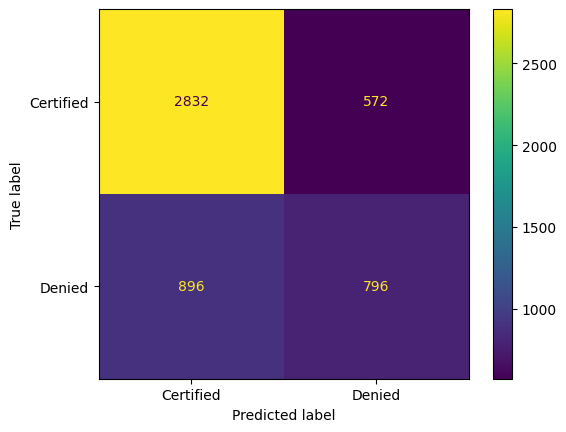

In [ ]:
# Use x_test_transformed for confusion instead of X_test to avoid data leakage and ensure consistency with the model's training data
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_model, x_test_transformed, y_test)